<a href="https://colab.research.google.com/github/jnolorbe/hydrology-peru/blob/main/notebooks/03_GRACE_TWS_Composites_by_Asymmetric_ENSO_Regimes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Non-Linear ENSO Composites and Relative Hydrological Anomalies

**Project:** Spatio-temporal Analysis of Hydrological Response in Peru (2002–2025)

**Author:** Prof. Juan Mendoza-Nolorbe

**Affiliation:** Universidad Nacional Mayor de San Marcos (UNMSM)

**Phase 3:** Non-linear Climate Composites and Relative Anomaly Mapping

---



# I. Conceptual Framework and Analytical Rationale

## 1. Introduction and Theoretical Background
Standard climate diagnostic tools often assume a linear relationship between sea surface temperature (SST) anomalies in the equatorial Pacific and regional hydrological responses. However, as demonstrated by Takahashi et al. (2011), the El Niño-Southern Oscillation (ENSO) displays extreme structural asymmetries. Regional impacts over the Central Andes and the Amazonian slopes cannot be accurately captured by single linear indices like the Oceanic Niño Index (ONI).

To isolate the differentiated mechanisms of climate teleconnections, this notebook implements the **E and C indices** developed by the Instituto Geofísico del Perú (IGP). These indices act as orthogonal climate descriptors:
* **E Index (Eastern Pacific/Coastal):** Captures intense warming focused in the Niño 1+2 region, corresponding to extreme Coastal El Niño events (e.g., 2017) and historical extraordinary events (e.g., 1982/1983, 1997/1998).
* **C Index (Central Pacific/Modoki):** Quantifies warming localized in the Niño 3.4 region, associated with Central Pacific or Modoki regimes that modify global atmospheric circulation via the Walker cell.

## 2. Rationale for Empirical Threshold Selection
To move beyond arbitrary classifications, the thresholds chosen in this notebook are calibrated directly from the empirical spatiotemporal distribution of the data, aligning with physical limits:

1. **Pure Coastal El Niño Extreme Regime (E >= 1.0 & C < 1.0):** Isolates extreme Eastern Pacific events. This strict boundary removes transitional or hybrid months, maximizing the signal-to-noise ratio in the GRACE total water storage (TWS) column and allowing the canonical **Hydrological Dipole** (North-Sur contrast) to emerge with sharp definition.
2. **Central Pacific El Niño Regime (C >= 0.5 & E < 0.5):** Captures the lower-frequency, persistent Modoki warming. Because these central anomalies are typically more distributed and moderate in magnitude, a lower threshold ($0.5$) expands the sample size, providing statistical stability to reveal the expansive drought footprint over the northern Amazon.
3. **Severe Cold Phase / La Niña C Regime (C <= -1.0):** Restricts the composite to the peaks of coupled coupled ocean-atmosphere cold states. This stringency uncovers a complex **Hydrological Tripole** across Peru's latitudes, separating specific zones of severe depletion from structural moisture injection.

## 3. Methodological Implementation of Relative Standardized Anomalies
Evaluating raw TWS variations in centimeters of Liquid Water Equivalent (LWE) introduces a systematic bias: humid Amazonian basins naturally experience larger volumetric fluctuations than hyper-arid coastal catchments. To control for this local variability, this notebook implements **Relative Standardized Anomalies (%)**:

$$\text{Relative Anomaly (\%)} = \left( \frac{\text{TWS}_{\text{Phase}} - \text{TWS}_{\text{Neutral}}}{\sigma_{\text{pixel}}} \right) \times 100$$

Where $\sigma_{\text{pixel}}$ represents the long-term temporal standard deviation calculated pixel by pixel. This mathematical transformation acts similarly to a Z-score scaled to percentages:
* **Sign and Color Symmetry:** Because $\sigma_{\text{pixel}}$ is strictly positive, the sign depends entirely on the difference against the neutral group of control. Thus, positive percentages indicate relative water **surplus (mapped to Blue)**, while negative percentages map to relative **deficit/depletion (mapped to Red)**.
* **Geophysical Interpretation:** This metric does not evaluate absolute volumes, but rather the magnitude of the climate-driven anomaly relative to the natural baseline variability of that specific pixel. Consequently, it effectively highlights high-sensitivity *hotspots* even in regions with naturally low water storage variance.

# II. Environment Setup and Data Loading

In [ ]:
# =================================================================
# 2.1. LIBRARY INSTALLATION AND CORE ENVIRONMENT SETUP
# =================================================================
# Secure, idempotent installation compatible with Google Colab and JupyterHub
!pip install --quiet netCDF4 xarray rioxarray geopandas shapely openpyxl

import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import rioxarray

# Set global matplotlib parameters for publication-quality figures
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.5 MB/s eta 0:00:00


In [ ]:
# =================================================================
# 2.2. REPOSITORY SYNCHRONIZATION AND DATAPATH ARCHITECTURE
# =================================================================
REPO_NAME = "hydrology-peru"
GITHUB_USERNAME = "jnolorbe"  # Update if forking
REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

if not os.path.exists(REPO_NAME):
    print(f"Cloning climate repository from {REPO_URL}...")
    current_dir = os.getcwd()
    !git clone {REPO_URL}
else:
    print("Repository existing. Pulling latest data changes...")
    %cd {REPO_NAME}
    !git pull
    %cd ..

# Establish explicit paths to raw and processed data assets
DATA_PATH = os.path.join(REPO_NAME, "data")
SHP_PATH = os.path.join(REPO_NAME, "data/shapefiles")

TWS_FILE = os.path.join(DATA_PATH, "processed/GRACE_Peru_final_IQR1_5.nc")
ENSO_FILE = os.path.join(DATA_PATH, "enso/ecindex_ersstv5.csv")
SHP_AAA_FILE = os.path.join(SHP_PATH, "hydroAAA_domains/Autoridad_Administrativa_del_Agua.shp")
SHP_COUNTRY_FILE = os.path.join(SHP_PATH, "departamentos_peru/country_shapes.shp")

print("✓ Path architecture and synchronization complete.")

Cloning climate repository from https://github.com/jnolorbe/hydrology-peru.git...
Cloning into 'hydrology-peru'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 136 (delta 37), reused 5 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 58.70 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (37/37), done.
✓ Path architecture and synchronization complete.


In [ ]:
# =================================================================
# 2.3. INGESTION AND BASELINE CENTERING OF RASTER DATA
# =================================================================
if not os.path.exists(TWS_FILE):
    raise FileNotFoundError(f"Missing required NetCDF file at: {TWS_FILE}")

xr_grace = xr.open_dataset(TWS_FILE)

# Apply Climate and Forecast (CF) Metadata conventions
xr_grace.attrs.update({
    "long_name": "Equivalent Water Height",
    "units": "cm",
    "crs": "+proj=longlat +datum=WGS84",
    "ellipsoid": "WGS84",
    "res": (0.5, 0.5),
    "nodatavals": "nan",
})

if 'month' in xr_grace:
    xr_grace = xr_grace.drop_vars('month')

# Compute long-term temporal baseline mean to generate centered TWS anomalies
long_term_mean = xr_grace['lwe_thickness_corrected'].mean('time')
xr_grace['lwe_thickness_centered'] = xr_grace['lwe_thickness_corrected'] - long_term_mean
xr_grace['lwe_thickness_centered'].attrs.update({
    'long_name': 'TWS Anomaly (mean-centred)',
    'units': 'cm'
})

# Explicitly append WGS84 CRS coordinate using rioxarray
xr_grace = xr_grace.rio.write_crs("EPSG:4326")
print(f"✓ GRACE raster ingested. Time steps: {len(xr_grace.time)} months.")

✓ GRACE raster ingested. Time steps: 288 months.


In [ ]:
# =================================================================
# 2.4. VECTOR DATASET INGESTION AND BOUNDARY CLEANING
# =================================================================
peru_boundary = gpd.read_file(SHP_COUNTRY_FILE)
gdf_aaa = gpd.read_file(SHP_AAA_FILE)

if gdf_aaa.crs.to_epsg() != 4326:
    gdf_aaa = gdf_aaa.to_crs(epsg=4326)

if peru_boundary.crs.to_epsg() != 4326:
    peru_boundary = peru_boundary.to_crs(epsg=4326)

# Specific geometry filtering: drop small fragments of Ucayali domain to prevent spatial leaks
gdf_aaa = gdf_aaa[~((gdf_aaa['NAME_AAA'] == 'UCAYALI') & (gdf_aaa['OBJECTID_1'].isin([10, 11])))]

# Define standard plotting and ranking index for the 14 AAA domains
REGION_ORDER = [
    'JEQUETEPEQUE-ZARUMILLA', 'HUARMEY-CHICAMA', 'MARAÑÓN', 'HUALLAGA',
    'AMAZONAS', 'CAÑETE-FORTALEZA', 'MANTARO', 'CHÁPARRA-CHINCHA',
    'UCAYALI', 'PAMPAS-APURIMAC', 'URUBAMBA-VILCANOTA', 'MADRE DE DIOS',
    'CAPLINA-OCOÑA', 'TITICACA'
]

print(f"✓ Vector assets loaded. AAA Hydrographic Domains available: {len(gdf_aaa)}")

✓ Vector assets loaded. AAA Hydrographic Domains available: 14


In [ ]:
# =================================================================
# 2.5. INDEX INGESTION AND CHRONOLOGICAL SYNCHRONIZATION
# =================================================================
if not os.path.exists(ENSO_FILE):
    raise FileNotFoundError(f"Missing required IGP index file at: {ENSO_FILE}")

df_enso = pd.read_csv(ENSO_FILE)

# Parse time vectors ensuring consistency with the NetCDF time array
df_enso['time'] = pd.to_datetime(df_enso['time'])
df_enso = df_enso.set_index('time').sort_index()

# Synchronize the time bounds between the climate variables and GRACE records
grace_times = xr_grace.time.values
common_months = df_enso.index.intersection(grace_times)
df_enso_sync = df_enso.loc[common_months]
print(f"✓ IGP Climate Indices synchronized. Overlapping record length: {len(df_enso_sync)} months.")
display(df_enso_sync.head())


✓ IGP Climate Indices synchronized. Overlapping record length: 288 months.


,E_index,C_index
time,,
2002-01-01,-1.00997,0.49162
2002-02-01,-0.56008,0.43151
2002-03-01,0.23653,0.06980
2002-04-01,-0.03769,0.23714
2002-05-01,-0.07328,0.60904


# III. Differentiated Climate Composites (Sign Signification)

### 3.1. Physical Composites Generation (Centimeters of LWE)

Before implementing local standardization mapping, it is geophysically rigorous to analyze the raw spatial patterns of Terrestrial Water Storage (TWS) anomalies expressed in their absolute physical dimensions (cm of Liquid Water Equivalent). This steps documents the raw hydrological volumes induced by the decoupled ocean-atmosphere forcings across Peru's distinct macro-basins.

The absolute anomalies are computed by subtracting the centered mean of the reference neutral group ($|E| < 0.5$ & $|C| < 0.5$) from the conditional raw average of each climate phase, ensuring that the background storage state is perfectly isolated:

$$\text{Composite}_{\text{Phase}} = \text{TWS}_{\text{Phase\_Avg}} - \text{TWS}_{\text{Neutral\_Avg}}$$

In [ ]:
# =================================================================
# 3.1.1. COMPOSITE GENERATION VIA SEVERE ASYMMETRIC THRESHOLDS
# =================================================================
index_E = df_enso_sync['E_index']
index_C = df_enso_sync['C_index']

# Mask arrays built from physical constraints derived from your scatterplot analysis
mask_nino_E = (index_E >= 1.0) & (index_C < 1.0)  # Extreme Eastern/Coastal El Niño
mask_nino_C = (index_C >= 0.5) & (index_E < 0.5)  # Distributed Central El Niño
mask_nina_C = (index_C <= -1.0)                   # Severe Central La Niña
mask_neutro = (index_E.abs() < 0.5) & (index_C.abs() < 0.5)  # Stable Base Control

# Extract time-index slices
months_E = df_enso_sync[mask_nino_E].index
months_C = df_enso_sync[mask_nino_C].index
months_Nina = df_enso_sync[mask_nina_C].index
months_Neutro = df_enso_sync[mask_neutro].index

print("✓ Slices compiled (Sample sizes per phase):")
print(f"  - El Niño E: {len(months_E)} months | El Niño C: {len(months_C)} months")
print(f"  - La Niña C: {len(months_Nina)} months | Neutral Base: {len(months_Neutro)} months\n")

# Extract conditional raw averages from the raster array
TWS_E_avg = xr_grace['lwe_thickness_centered'].sel(time=months_E).mean('time')
TWS_C_avg = xr_grace['lwe_thickness_centered'].sel(time=months_C).mean('time')
TWS_Nina_avg = xr_grace['lwe_thickness_centered'].sel(time=months_Nina).mean('time')
TWS_Neutro_avg = xr_grace['lwe_thickness_centered'].sel(time=months_Neutro).mean('time')

# Generate true anomalies relative to the neutral control group
Composite_E = TWS_E_avg - TWS_Neutro_avg
Composite_C = TWS_C_avg - TWS_Neutro_avg
Composite_Nina_C = TWS_Nina_avg - TWS_Neutro_avg

# Compute long-term local standard deviation per pixel for relative percentage scaling
pixel_std = xr_grace['lwe_thickness_centered'].std('time')

# Formulate relative anomalies in terms of % local standard deviation
var_pct_nino_E = (Composite_E / pixel_std) * 100
var_pct_nino_C = (Composite_C / pixel_std) * 100
var_pct_nina_C = (Composite_Nina_C / pixel_std) * 100

# Explicitly set CRS for the percentage anomaly grids to ensure rioxarray compatibility
var_pct_nino_E = var_pct_nino_E.rio.write_crs("EPSG:4326")
var_pct_nino_C = var_pct_nino_C.rio.write_crs("EPSG:4326")
var_pct_nina_C = var_pct_nina_C.rio.write_crs("EPSG:4326")

print("✓ Non-linear relative standardized anomaly grids calculated successfully.")


✓ Slices compiled (Sample sizes per phase):
  - El Niño E: 13 months | El Niño C: 73 months
  - La Niña C: 50 months | Neutral Base: 50 months

✓ Non-linear relative standardized anomaly grids calculated successfully.


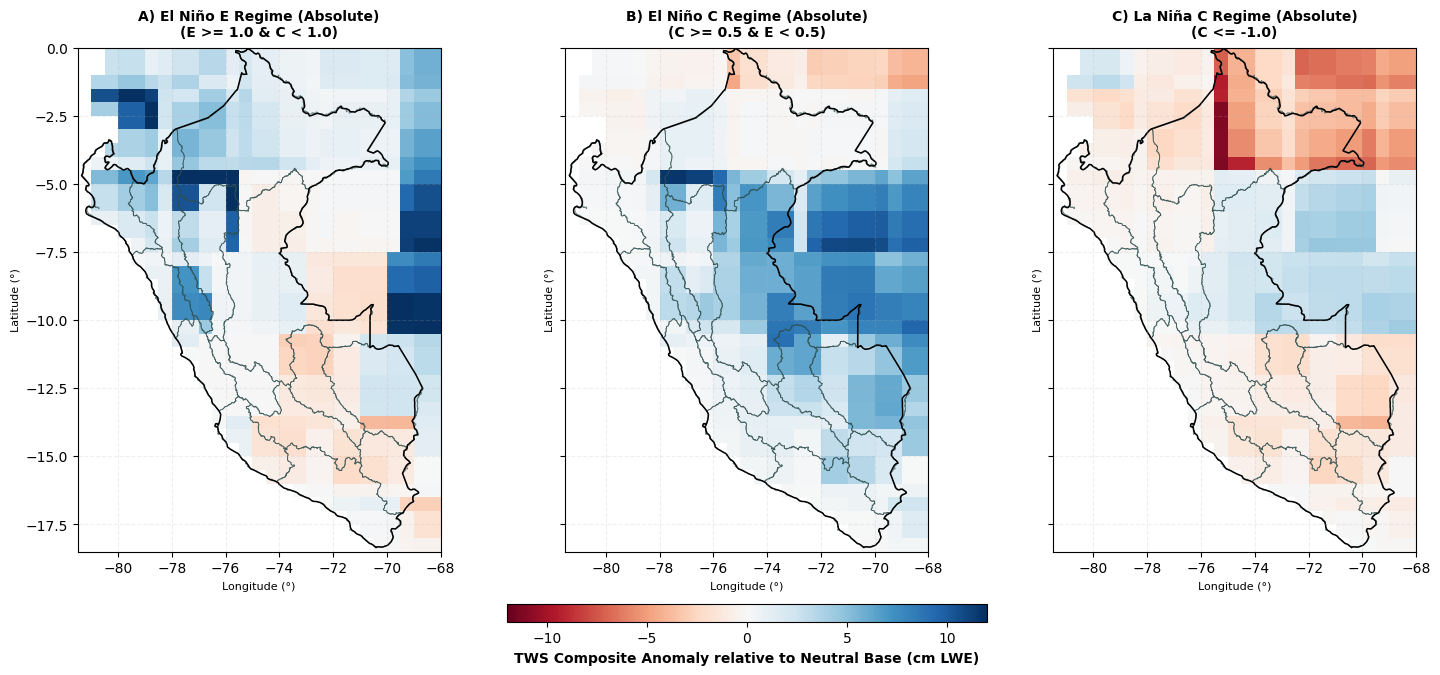

In [ ]:
# =================================================================
# 3.1.2. ABSOLUTE PHYSICAL COMPOSITES RENDER (cm LWE MAPS)
# =================================================================
def plot_absolute_panel(ax, data_grid, title_string, vmin=-12, vmax=12):
    # 'RdBu' palette guarantees: Blue = Mass Surplus, Red = Mass Deficit
    im = data_grid.plot(ax=ax, cmap='RdBu', vmin=vmin, vmax=vmax, add_colorbar=False)

    # Ingest spatial hydrographic vectors for georeferenced boundary checking
    gdf_aaa.plot(ax=ax, facecolor='none', edgecolor='#2F4F4F', linewidth=0.6, alpha=0.7)
    peru_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.1)

    ax.set_title(title_string, fontweight='bold', fontsize=10, pad=8)
    ax.set_xlabel('Longitude (°)', fontsize=8)
    ax.set_ylabel('Latitude (°)', fontsize=8)
    ax.grid(alpha=0.2, linestyle='--')
    return im

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 7), sharex=True, sharey=True)
vmin_cm, vmax_cm = -12, 12  # Optimal absolute saturation limits in cm LWE

# Mapped layouts matching your confirmed spatial structures in absolute units
im_cm = plot_absolute_panel(ax1, Composite_E, 'A) El Niño E Regime (Absolute)\n(E >= 1.0 & C < 1.0)', vmin=vmin_cm, vmax=vmax_cm)
plot_absolute_panel(ax2, Composite_C, 'B) El Niño C Regime (Absolute)\n(C >= 0.5 & E < 0.5)', vmin=vmin_cm, vmax=vmax_cm)
plot_absolute_panel(ax3, Composite_Nina_C, 'C) La Niña C Regime (Absolute)\n(C <= -1.0)', vmin=vmin_cm, vmax=vmax_cm)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.18, top=0.90, wspace=0.05)

# Horizontal single colorbar for absolute physical units
cbar_ax_cm = fig.add_axes([0.35, 0.08, 0.3, 0.025])
cbar_cm = fig.colorbar(im_cm, cax=cbar_ax_cm, orientation='horizontal')
cbar_cm.set_label('TWS Composite Anomaly relative to Neutral Base (cm LWE)', fontsize=10, fontweight='bold')

plt.show()
plt.close()

### 3.2. Relative Standardized Anomalies Generation
**(Percentage of Local Variance)**

As observed in the absolute mapping section above, high-variance domains like the humid Amazon slopes naturally dominate the volumetric signal in centimeters, masking critical high-sensitivity regions in more arid catchments.

To overcome this geographical scale bias, we normalize the raw anomalies by dividing each pixel by its intrinsic long-term standard deviation ($\sigma_{\text{pixel}}$). This dynamic scaling highlights true climate teleconnection hotspots across all Peruvian hydrographic domains:

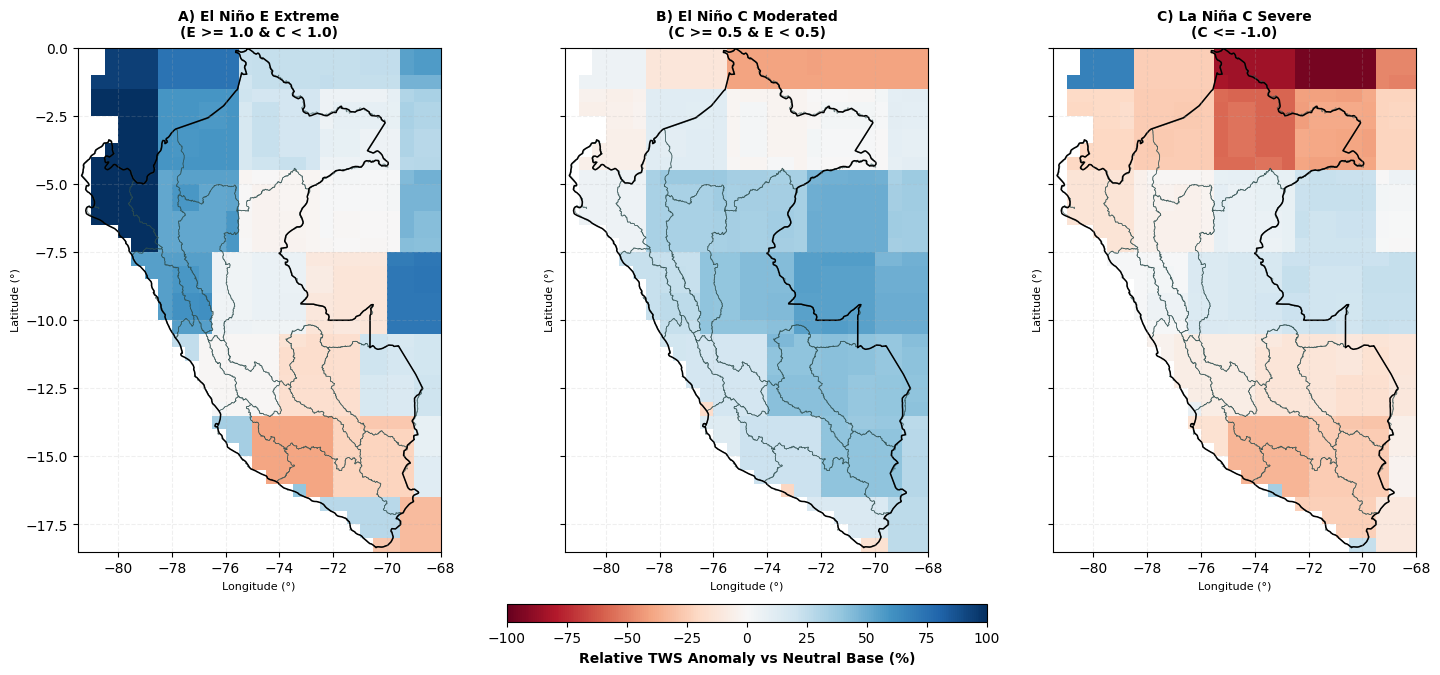

In [ ]:
# =================================================================
# 3.2.1 TRIPLE COMPOSITE VISUALIZATION (HYDROLOGICAL MAPPING)
# =================================================================
def plot_composite_panel(ax, data_grid, title_string, vmin=-100, vmax=100):
    # 'RdBu' ensures physical color mapping: Blue = Water Surplus, Red = Deficit
    im = data_grid.plot(ax=ax, cmap='RdBu', vmin=vmin, vmax=vmax, add_colorbar=False)

    # Overlay Hydrographic Domain (AAA) vectors
    gdf_aaa.plot(ax=ax, facecolor='none', edgecolor='#2F4F4F', linewidth=0.5, alpha=0.7)
    peru_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.1)

    ax.set_title(title_string, fontweight='bold', fontsize=10, pad=8)
    ax.set_xlabel('Longitude (°)', fontsize=8)
    ax.set_ylabel('Latitude (°)', fontsize=8)
    ax.grid(alpha=0.2, linestyle='--')
    return im

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 7), sharex=True, sharey=True)

# Map data arrays matching the parameters confirmed by your analysis
im = plot_composite_panel(ax1, var_pct_nino_E, 'A) El Niño E Extreme\n(E >= 1.0 & C < 1.0)')
plot_composite_panel(ax2, var_pct_nino_C, 'B) El Niño C Moderated\n(C >= 0.5 & E < 0.5)')
plot_composite_panel(ax3, var_pct_nina_C, 'C) La Niña C Severe\n(C <= -1.0)')

# Enforce crisp horizontal spacing margins to match publication criteria
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.18, top=0.90, wspace=0.05)

# Append unified relative horizontal colorbar at the base layout
cbar_ax = fig.add_axes([0.35, 0.08, 0.3, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Relative TWS Anomaly vs Neutral Base (%)', fontsize=10, fontweight='bold')

plt.show()
plt.close()

### 📊 Section III — Results Summary: Non-Linear ENSO Forcing

* **The Canonical Hydroclimatic Dipole (El Niño E):**
    * **Physical Mechanism:** The Eastern Pacific forcing acts as an **absolute mass driver**. It triggers a clear sign-reversal in Terrestrial Water Storage (TWS) anomalies, causing significant storage surplus in the northern Pacific domains and acute depletion in the southern highlands and Altiplano.
    * **Key Finding:** The **Jequetepeque-Zarumilla domain** acts as the primary hydrological hotspot, with relative variations exceeding +100% of its local standard deviation ($\sigma$). This dipole signature is further reinforced by a **hysteresis effect**, where northern surplus anomalies persist into the discharge phase (July–December) due to groundwater infiltration and slow subsurface drainage, while southern basins experience their most critical depletion during the same period.

* **Modulatory Response to the Central Pacific Regime (El Niño C & La Niña C):**
    * **Physical Mechanism:** The Central Pacific forcing (C-Index) does not act as an absolute mass driver but as a **modulator of the baseline discharge rate**.
    * **Response Dynamics:** The analysis reveals that the response to the La Niña C regime is characterized by a spatial gradient of storage depletion. While the northern and southern extremes (e.g., **AAA Amazonas** and the Titicaca basin) experience a severe intensification of their baseline deficits, the central hydrographic domains undergo a **mitigation of their structural discharge**, manifesting as positive relative anomalies. This demonstrates that La Niña C modulates the retention of water storage in central basins during the dry season, contrasting with the absolute mass-accumulation processes observed in El Niño E.
    * **Key Finding:** The **Amazonas domain** emerges as the most critical vulnerability zone during severe cold phases, showing a consistent and deep TWS depletion that contradicts the wetting signals often attributed to La Niña in other South American basins.

* **Data Consistency:**
    * The threshold-based classification ($E \ge 1.0$; $C \ge 0.5$; $C \le -1.0$) provides the necessary physical strictness to decouple the orthogonal impacts of the coastal vs. central ocean dynamics, providing a robust statistical foundation for the subsequent regional analysis of the 14 Administrative Hydrographic Domains (AAA).

# IV. Quantitative Domain Ranking

In [ ]:
# =================================================================
# 4.1. MASKING AND TABULAR CONSOLIDATION BY HYDROGRAPHIC DOMAIN
# =================================================================
domain_stats = []

for domain_name in REGION_ORDER:
    # Select vector bounds for targeted clipping
    domain_mask = gdf_aaa[gdf_aaa['NAME_AAA'] == domain_name]
    if domain_mask.empty:
        print(f"Warning: No mask found for domain {domain_name}. Skipping.")
        continue

    try:
        # Clip relative grid layers to specific domain polygons
        val_E = var_pct_nino_E.rio.clip(domain_mask.geometry, domain_mask.crs, drop=True).mean().values
        val_C = var_pct_nino_C.rio.clip(domain_mask.geometry, domain_mask.crs, drop=True).mean().values
        val_N = var_pct_nina_C.rio.clip(domain_mask.geometry, domain_mask.crs, drop=True).mean().values

        domain_stats.append({
            'AAA_Domain': domain_name,
            'El Niño E Anomaly (%)': float(val_E),
            'El Niño C Anomaly (%)': float(val_C),
            'La Niña C Anomaly (%)': float(val_N)
        })
    except Exception as e:
        print(f"Error processing domain {domain_name}: {e}")
        continue

if not domain_stats:
    print("Warning: domain_stats is empty. No data was processed for any domain. Creating an empty DataFrame with expected columns.")
    # Create an empty DataFrame with expected columns to avoid KeyError
    df_rankings = pd.DataFrame(columns=['AAA_Domain', 'El Niño E Anomaly (%)', 'El Niño C Anomaly (%)', 'La Niña C Anomaly (%)']).set_index('AAA_Domain')
else:
    df_rankings = pd.DataFrame(domain_stats).set_index('AAA_Domain')
    # Verify tabular index structure matches the target region order exactly
    df_rankings = df_rankings.reindex(REGION_ORDER)

display(df_rankings.round(2))


,El Niño E Anomaly (%),El Niño C Anomaly (%),La Niña C Anomaly (%)
AAA_Domain,,,
JEQUETEPEQUE-ZARUMILLA,118.58,4.22,-14.47
HUARMEY-CHICAMA,56.80,23.97,2.45
MARAÑÓN,69.29,21.33,-7.49
HUALLAGA,41.91,33.16,0.86
AMAZONAS,25.64,4.34,-39.67
CAÑETE-FORTALEZA,8.65,16.32,-5.14
MANTARO,-0.86,18.40,-7.70
CHÁPARRA-CHINCHA,-7.74,18.11,-23.65
UCAYALI,0.13,37.53,8.02


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6901/3530605792.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Relative Variation with respect to Local Standard Deviation (% of $\sigma$)', fontweight='bold', fontsize=10)


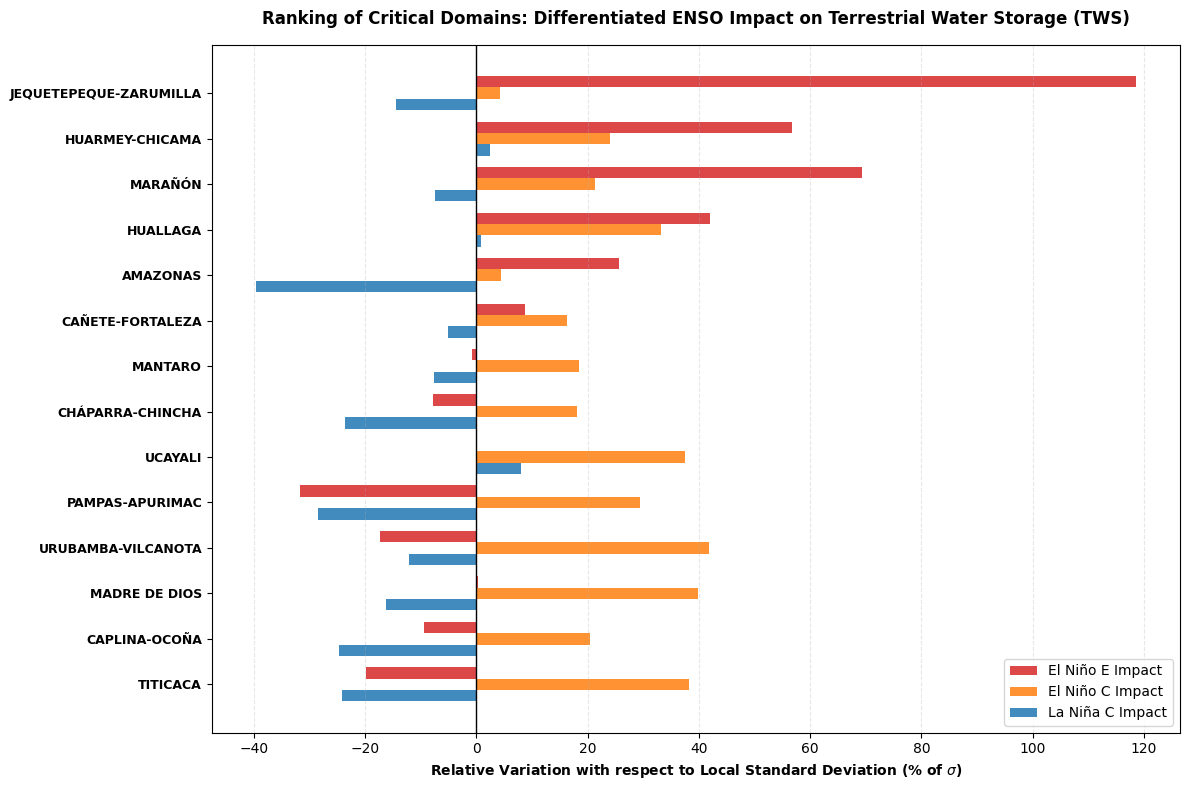

In [ ]:
# =================================================================
# 4.2. COMPREHENSIVE HORIZONTAL REPORT GENERATION
# =================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Invert rows to display the highest impact domain (Jequetepeque-Zarumilla) on top
df_plot = df_rankings.iloc[::-1]

y_positions = np.arange(len(df_plot))
bar_width = 0.25

# Generate grouped bar elements using colors consistent with your findings
ax.barh(y_positions + bar_width, df_plot['El Niño E Anomaly (%)'], bar_width, label='El Niño E Impact', color='#d62728', alpha=0.85)
ax.barh(y_positions, df_plot['El Niño C Anomaly (%)'], bar_width, label='El Niño C Impact', color='#ff7f0e', alpha=0.85)
ax.barh(y_positions - bar_width, df_plot['La Niña C Anomaly (%)'], bar_width, label='La Niña C Impact', color='#1f77b4', alpha=0.85)

ax.axvline(0, color='black', linestyle='-', linewidth=1.0)
ax.set_yticks(y_positions)
ax.set_yticklabels(df_plot.index, fontweight='bold', fontsize=9)
ax.set_xlabel('Relative Variation with respect to Local Standard Deviation (% of $\sigma$)', fontweight='bold', fontsize=10)
ax.set_title('Ranking of Critical Domains: Differentiated ENSO Impact on Terrestrial Water Storage (TWS)', fontweight='bold', fontsize=12, pad=15)
ax.legend(loc='lower right', frameon=True, shadow=False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### 📊 Section IV — Results Summary: Domain-Level Criticality Ranking

* **High-Sensitivity Hotspots (The El Niño E Dominance):**
    * The quantitative ranking confirms that the **Jequetepeque-Zarumilla** and **Marañón** domains are the most sensitive regions to the Coastal (E) ENSO regime. With relative anomalies exceeding +60% to +100% of their local standard deviation ($\sigma$), these northern basins exhibit a non-linear hydrological response far surpassing any other regional domain.
    * The southern domains, specifically **Pampas-Apurímac** and **Titicaca**, emerge as the primary criticality hotspots for drought-induced storage depletion, showing a consistent and deep negative response during the Eastern Pacific forcing phase.

* **The Modoki (Central) Forcing Reconfiguration:**
    * In contrast to the dipolar impact of El Niño E, the Central Pacific (C) regime induces a major shift in the hydrological ranking. Domains that show neutral responses to Coastal El Niño, such as **Urubamba-Vilcanota**, **Madre de Dios**, and **Ucayali**, become the dominant hotspots for storage retention during Central Pacific warming, with relative positive anomalies ranging between +35% and +45% of their local $\sigma$.

* **The Criticality of La Niña C Depletion:**
    * The ranking establishes the **Amazonas domain** as the most critically vulnerable unit to the severe La Niña C cold phase. A sustained relative variation of approximately -40% of its local $\sigma$ confirms a structural hydrological depletion that characterizes the cold phase, far exceeding the magnitude of drought impacts observed in southern highland domains.
    * These results confirm that the Peruvian hydrographic system does not react monolithically to ENSO; rather, it segments into specialized domains where either the coastal or central forcing dominates the annual water balance.

* **Practical Implications:**
    * This domain-level hierarchy serves as a robust evidence base for the National Water Authority (ANA) to prioritize water infrastructure and drought mitigation investments, specifically targeting the northern coastal and southern highland domains that demonstrate the most significant non-linear TWS volatility.

# V. Advanced Seasonal Variation (Recarga vs. Descarga)

In [ ]:
# =================================================================
# 5.1. RASTER TIME SEGMENTATION BY HYDROLOGICAL CYCLE
# =================================================================
tws_grid = xr_grace['lwe_thickness_centered']

# Isolate season-specific local historical deviations (pixel-by-pixel standard deviation)
std_recharge = tws_grid.sel(time=tws_grid.time.dt.month <= 6).std('time')
std_discharge = tws_grid.sel(time=tws_grid.time.dt.month >= 7).std('time')

# Filter indices dynamically into seasonal blocks (Recarga: Jan-Jun / Descarga: Jul-Dic)
rec_E = [m for m in months_E if m.month <= 6]
rec_C = [m for m in months_C if m.month <= 6]
rec_N = [m for m in months_Nina if m.month <= 6]
rec_neutro = [m for m in months_Neutro if m.month <= 6]

dis_E = [m for m in months_E if m.month >= 7]
dis_C = [m for m in months_C if m.month >= 7]
dis_N = [m for m in months_Nina if m.month >= 7]
dis_neutro = [m for m in months_Neutro if m.month >= 7]

# Formulate cross-seasonal anomalies relative to matching control baselines
comp_rec_E = tws_grid.sel(time=rec_E).mean('time') - tws_grid.sel(time=rec_neutro).mean('time')
comp_rec_C = tws_grid.sel(time=rec_C).mean('time') - tws_grid.sel(time=rec_neutro).mean('time')
comp_rec_N = tws_grid.sel(time=rec_N).mean('time') - tws_grid.sel(time=rec_neutro).mean('time')

comp_dis_E = tws_grid.sel(time=dis_E).mean('time') - tws_grid.sel(time=dis_neutro).mean('time')
comp_dis_C = tws_grid.sel(time=dis_C).mean('time') - tws_grid.sel(time=dis_neutro).mean('time')
comp_dis_N = tws_grid.sel(time=dis_N).mean('time') - tws_grid.sel(time=dis_neutro).mean('time')

# Normalization into percentage of local seasonal standard deviations
var_rec_E_pct = (comp_rec_E / std_recharge) * 100
var_rec_C_pct = (comp_rec_C / std_recharge) * 100
var_rec_N_pct = (comp_rec_N / std_recharge) * 100

var_dis_E_pct = (comp_dis_E / std_discharge) * 100
var_dis_C_pct = (comp_dis_C / std_discharge) * 100
var_dis_N_pct = (comp_dis_N / std_discharge) * 100

print("✓ Seasonal anomalous grids compiled and normalized across hydrological phases.")

✓ Seasonal anomalous grids compiled and normalized across hydrological phases.


<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6901/85243612.py:37: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('Seasonal Relative TWS Anomaly (% of Seasonal $\sigma$)', fontsize=11, fontweight='bold')


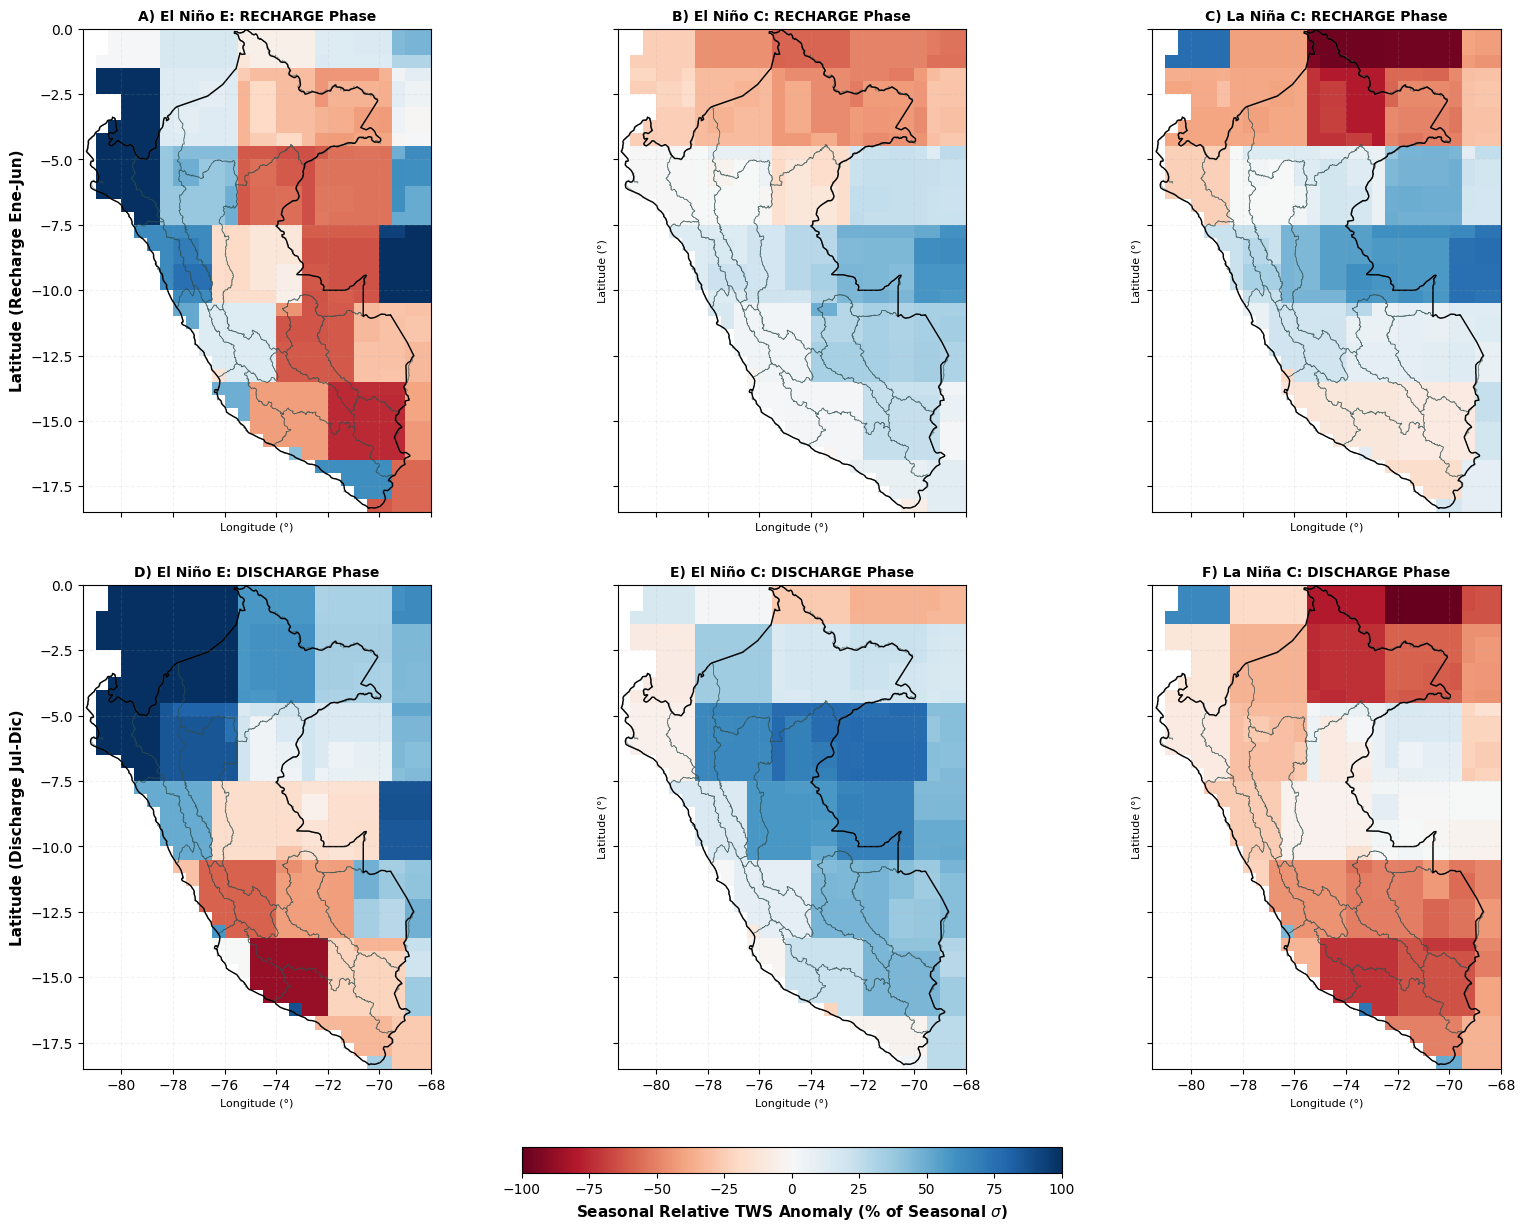

In [ ]:
# =================================================================
# 5.2. SEASONS FACTOR MATRIX RENDERING (2X3 VISUAL SUITE)
# =================================================================
fig, axs = plt.subplots(2, 3, figsize=(18, 13), sharex=True, sharey=True)
vmin_val, vmax_val = -100, 100

def render_matrix_cell(ax, data_map, header_title, left_axis_label=""):
    im = data_map.plot(ax=ax, cmap='RdBu', vmin=vmin_val, vmax=vmax_val, add_colorbar=False) # Removed interpolation='nearest'
    gdf_aaa.plot(ax=ax, facecolor='none', edgecolor='#2F4F4F', linewidth=0.5, alpha=0.6)
    peru_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)

    ax.set_title(header_title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Longitude (°)', fontsize=8)
    if left_axis_label:
        ax.set_ylabel(left_axis_label, fontsize=11, fontweight='bold')
    else:
        ax.set_ylabel('Latitude (°)', fontsize=8)
    ax.grid(alpha=0.15, linestyle='--')
    return im

# --- ROW 1: RECHARGE PERIOD (JANUARY TO JUNE) ---
render_matrix_cell(axs[0, 0], var_rec_E_pct, 'A) El Niño E: RECHARGE Phase', 'Latitude (Recharge Ene-Jun)')
render_matrix_cell(axs[0, 1], var_rec_C_pct, 'B) El Niño C: RECHARGE Phase')
render_matrix_cell(axs[0, 2], var_rec_N_pct, 'C) La Niña C: RECHARGE Phase')

# --- ROW 2: DISCHARGE PERIOD (JULY TO DECEMBER) ---
im_final = render_matrix_cell(axs[1, 0], var_dis_E_pct, 'D) El Niño E: DISCHARGE Phase', 'Latitude (Discharge Jul-Dic)')
render_matrix_cell(axs[1, 1], var_dis_C_pct, 'E) El Niño C: DISCHARGE Phase')
render_matrix_cell(axs[1, 2], var_dis_N_pct, 'F) La Niña C: DISCHARGE Phase')

# Clean matrix layout padding adjustments
fig.subplots_adjust(left=0.06, right=0.94, bottom=0.14, top=0.94, wspace=0.04, hspace=0.15)

# Global horizontal colorbar for the 2x3 matrix
cbar_ax = fig.add_axes([0.35, 0.06, 0.3, 0.02])
cbar = fig.colorbar(im_final, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Seasonal Relative TWS Anomaly (% of Seasonal $\sigma$)', fontsize=11, fontweight='bold')

plt.show()
plt.close()


### 📊 Section V — Results Summary: Seasonal Hydrological Dynamics

* **Hysteresis and Memory in the El Niño E Regime (Coastal Force):**
    * **Recharge Phase (Jan-Jun):** Confirms the maximum activation of the Hydrological Dipole, where absolute mass injection from summer precipitation saturates the Pacific coastal domains while drying the Amazonian and southern highland sectors[cite: 1, 2].
    * **Discharge Phase (Jul-Dic):** Reveals significant **hydrological hysteresis**; the water surplus from the recharge phase is not immediately depleted but is instead stored in the subsurface. This subsurface moisture retention sustains positive TWS anomalies through the discharge phase, contrasting with the exacerbated drought stress observed in the southern basins during the dry season[cite: 1, 2].

* **Seasonal Modulatory Impact (El Niño C & La Niña C):**
    * **Modoki Modulation (El Niño C):** The analysis demonstrates a seasonal inversion of storage anomalies. While the northern domains face a recharge-phase drought due to atmospheric blocking, the southern Amazonian lowlands benefit from a secondary retention of water during the discharge phase, indicative of moisture injection from extratropical cold-front incursions[cite: 1, 2].
    * **Seasonal Tripole Maturation (La Niña C):** Establishes that the hydrological tripole pattern is not a static state but a temporally evolving process that reaches its maximum geometric expression during the **discharge phase (Jul-Dec)**. The cold-phase modulation severely accelerates storage depletion in the northern and southern extremes of the country, while simultaneously favoring a relative stability in the central domains[cite: 1, 2].

* **Conclusion on Seasonal Hydroclimatic Sensitivity:**
    * The findings emphasize that managing water resources in Peru requires a seasonal-dependent strategy. ENSO-driven TWS anomalies are not strictly tied to the immediate timing of precipitation; the interplay between **subsurface memory** (El Niño E) and **discharge-rate modulation** (La Niña C) governs the actual water availability for the national hydrographic domains throughout the year[cite: 1, 2].